# Revenue Analysis

This notebook analyzes revenue performance over time and across product categories.

In [1]:
import pandas as pd
from pathlib import Path

DATA_DIR = Path("../data/raw")

orders = pd.read_csv(
    DATA_DIR / "olist_orders_dataset.csv",
    parse_dates=["order_purchase_timestamp"]
)

order_items = pd.read_csv(
    DATA_DIR / "olist_order_items_dataset.csv"
)

## Revenue Over Time

Revenue is attributed to the month of the order purchase date.

In this analysis, revenue refers to the total product value recorded in `order_items.price`. Freight charges are excluded.

In [2]:
revenue_by_month = (
    order_items
    .merge(
        orders[["order_id", "order_purchase_timestamp"]],
        on="order_id",
        how="left",
        validate="many_to_one"
    )
)

In [3]:
revenue_by_month["month"] = (
    revenue_by_month["order_purchase_timestamp"]
    .dt.to_period("M")
)

In [ ]:
monthly_revenue = (
    revenue_by_month
    .groupby("month", as_index=False)["price"]
    .sum()
    .rename(columns={"price": "revenue"})
)

monthly_revenue.head()

,month,revenue
0,2016-09,267.36
1,2016-10,49507.66
2,2016-12,10.90
3,2017-01,120312.87
4,2017-02,247303.02


In [5]:
monthly_revenue.tail()

,month,revenue
19,2018-05,996517.68
20,2018-06,865124.31
21,2018-07,895507.22
22,2018-08,854686.33
23,2018-09,145.00


In [6]:
monthly_orders = (
    orders
    .groupby(orders["order_purchase_timestamp"].dt.to_period("M"))
    .agg(orders=("order_id", "nunique"))
    .reset_index()
    .rename(columns={"order_purchase_timestamp": "month"})
)

monthly_orders.head()

,month,orders
0,2016-09,4
1,2016-10,324
2,2016-12,1
3,2017-01,800
4,2017-02,1780


In [7]:
monthly_performance = monthly_revenue.merge(
    monthly_orders,
    on="month",
    how="left",
    validate="one_to_one"
)

monthly_performance["revenue_per_order"] = (
    monthly_performance["revenue"]
    / monthly_performance["orders"]
)

monthly_performance

,month,revenue,orders,revenue_per_order
0,2016-09,267.36,4,66.840000
1,2016-10,49507.66,324,152.801420
2,2016-12,10.90,1,10.900000
3,2017-01,120312.87,800,150.391087
4,2017-02,247303.02,1780,138.934281
5,2017-03,374344.30,2682,139.576547
6,2017-04,359927.23,2404,149.720146
7,2017-05,506071.14,3700,136.775984
8,2017-06,433038.60,3245,133.447951
9,2017-07,498031.48,4026,123.703795


In [8]:
monthly_performance["month"] = monthly_performance["month"].dt.to_timestamp()

full_months = pd.date_range(
    start=monthly_performance["month"].min(),
    end=monthly_performance["month"].max(),
    freq="MS"
)

monthly_performance = (
    monthly_performance
    .set_index("month")
    .reindex(full_months)
    .rename_axis("month")
    .reset_index()
)

monthly_performance[["revenue", "orders"]] = (
    monthly_performance[["revenue", "orders"]]
    .fillna(0)
)

import numpy as np

monthly_performance["revenue_per_order"] = (
    monthly_performance["revenue"]
    / monthly_performance["orders"].replace(0, np.nan)
)

The analysis focuses on January 2017 through August 2018.

The earlier 2016 observations represent a very limited period of activity and are not considered representative of the business trend.

In [9]:
analysis_revenue = monthly_performance[
    (monthly_performance["month"] >= "2017-01-01") &
    (monthly_performance["month"] <= "2018-08-01")
].copy()

analysis_revenue.head()

,month,revenue,orders,revenue_per_order
4,2017-01-01,120312.87,800.0,150.391087
5,2017-02-01,247303.02,1780.0,138.934281
6,2017-03-01,374344.30,2682.0,139.576547
7,2017-04-01,359927.23,2404.0,149.720146
8,2017-05-01,506071.14,3700.0,136.775984


In [10]:
analysis_revenue.tail()

,month,revenue,orders,revenue_per_order
19,2018-04-01,996647.75,6939.0,143.629882
20,2018-05-01,996517.68,6873.0,144.990205
21,2018-06-01,865124.31,6167.0,140.282846
22,2018-07-01,895507.22,6292.0,142.324733
23,2018-08-01,854686.33,6512.0,131.247901


In [11]:
import matplotlib.pyplot as plt

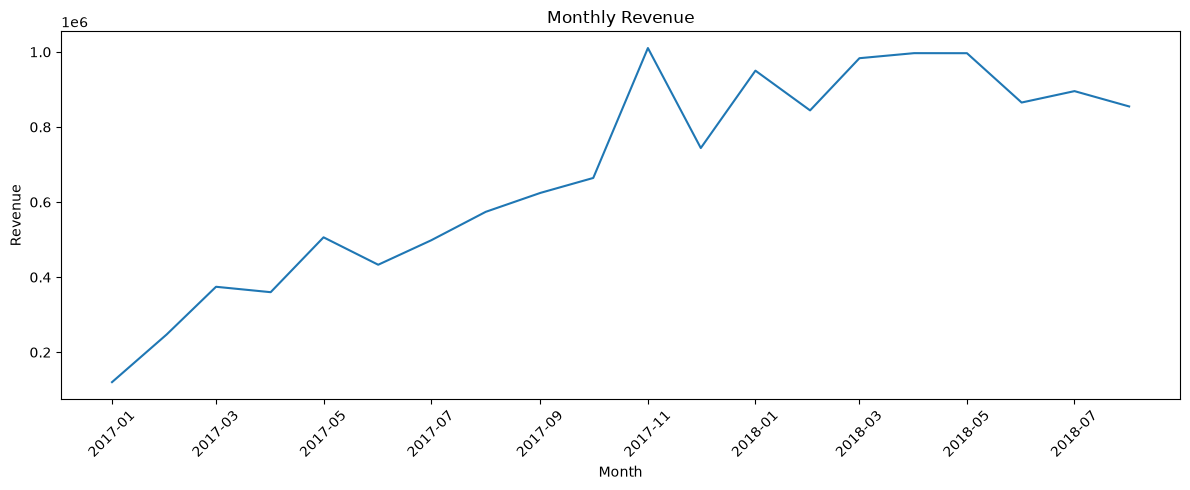

In [12]:
plt.figure(figsize=(12, 5))

plt.plot(
    analysis_revenue["month"],
    analysis_revenue["revenue"]
)

plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

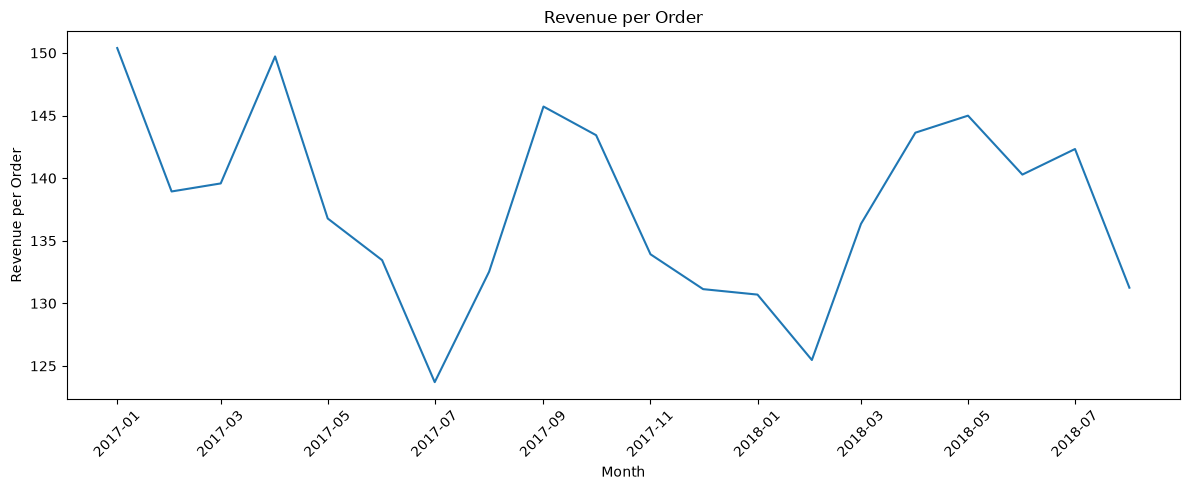

In [13]:
plt.figure(figsize=(12, 5))

plt.plot(
    analysis_revenue["month"],
    analysis_revenue["revenue_per_order"]
)

plt.title("Revenue per Order")
plt.xlabel("Month")
plt.ylabel("Revenue per Order")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [14]:
revenue_summary = pd.DataFrame(
    {
        "metric": [
            "2017 Revenue",
            "2018 Revenue (Jan-Aug)",
            "2017 Orders",
            "2018 Orders (Jan-Aug)",
        ],
        "value": [
            analysis_revenue.loc[
                analysis_revenue["month"].dt.year == 2017, "revenue"
            ].sum(),
            analysis_revenue.loc[
                (analysis_revenue["month"].dt.year == 2018), "revenue"
            ].sum(),
            analysis_revenue.loc[
                analysis_revenue["month"].dt.year == 2017, "orders"
            ].sum(),
            analysis_revenue.loc[
                analysis_revenue["month"].dt.year == 2018, "orders"
            ].sum(),
        ],
    }
)

revenue_summary

,metric,value
0,2017 Revenue,6155806.98
1,2018 Revenue (Jan-Aug),7385905.80
2,2017 Orders,45101.00
3,2018 Orders (Jan-Aug),53991.00


In [15]:
revenue_growth = (
    revenue_summary.loc[1, "value"]
    / revenue_summary.loc[0, "value"]
    - 1
)

orders_growth = (
    revenue_summary.loc[3, "value"]
    / revenue_summary.loc[2, "value"]
    - 1
)

revenue_growth, orders_growth

(np.float64(0.1998273864006046), np.float64(0.19711314604997665))

In [16]:
yoy_comparison = (
    analysis_revenue[
        analysis_revenue["month"].dt.year.isin([2017, 2018])
    ]
    .assign(
        year=analysis_revenue["month"].dt.year,
        month_num=analysis_revenue["month"].dt.month
    )
    .query("month_num <= 8")
    .groupby("year")
    .agg(
        revenue=("revenue", "sum"),
        orders=("orders", "sum")
    )
)

yoy_comparison["revenue_per_order"] = (
    yoy_comparison["revenue"] / yoy_comparison["orders"]
)

yoy_comparison

,revenue,orders,revenue_per_order
year,,,
2017,3113000.32,22968.0,135.536412
2018,7385905.80,53991.0,136.798833


In [17]:
yoy_revenue_growth = (
    yoy_comparison.loc[2018, "revenue"]
    / yoy_comparison.loc[2017, "revenue"]
    - 1
)

yoy_orders_growth = (
    yoy_comparison.loc[2018, "orders"]
    / yoy_comparison.loc[2017, "orders"]
    - 1
)

yoy_aov_change = (
    yoy_comparison.loc[2018, "revenue_per_order"]
    / yoy_comparison.loc[2017, "revenue_per_order"]
    - 1
)

yoy_revenue_growth, yoy_orders_growth, yoy_aov_change

(np.float64(1.3726003985762523),
 np.float64(1.3507053291536049),
 np.float64(0.009314255236972047))

## Key Finding

Revenue increased by 137.3% between January-August 2017 and January-August 2018.

The increase was primarily driven by order volume, which grew by 135.1%, while revenue per order increased by only 0.9%.

This suggests that the observed revenue growth was mainly volume-driven rather than the result of a meaningful increase in the value of individual orders.

## Revenue by Product Category

This analysis compares product categories based on total product revenue.

Revenue is calculated from `price` in `order_items` and attributed to the product category associated with each item.

In [18]:
products = pd.read_csv(
    DATA_DIR / "olist_products_dataset.csv"
)

category_translation = pd.read_csv(
    DATA_DIR / "product_category_name_translation.csv"
)

Now, before joining, we'll do a little check. Because the category name in `products` is in Portuguese and the translation file has its English mapping.

In [19]:
products[["product_id", "product_category_name"]].head()

,product_id,product_category_name
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria
1,3aa071139cb16b67ca9e5dea641aaa2f,artes
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer
3,cef67bcfe19066a932b7673e239eb23d,bebes
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas


In [20]:
category_translation.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


The output is exactly as expected. `products` has the category name in Portuguese, for example `perfumaria` and `esporte_lazer`, and the translation file maps the same `product_category_name` to the English name.

In [22]:
products_with_category = products.merge(
    category_translation,
    on="product_category_name",
    how="left",
    validate="many_to_one"
)

Checking that no translations are missing for products that have categories:

In [23]:
products_with_category["product_category_name_english"].isna().sum()

np.int64(623)

In [24]:
products_with_category.shape

(32951, 10)

In [25]:
products_with_category[
    products_with_category["product_category_name_english"].isna()
]["product_category_name"].value_counts(dropna=False)

product_category_name
NaN                                              610
portateis_cozinha_e_preparadores_de_alimentos     10
pc_gamer                                           3
Name: count, dtype: int64

In [26]:
products_with_category["product_category_name"].isna().sum()

np.int64(610)

In [27]:
order_items_with_category = order_items.merge(
    products_with_category[
        [
            "product_id",
            "product_category_name",
            "product_category_name_english",
        ]
    ],
    on="product_id",
    how="left",
    validate="many_to_one"
)

In [28]:
uncategorized_revenue = order_items_with_category.loc[
    order_items_with_category["product_category_name"].isna(),
    "price"
].sum()

uncategorized_revenue

np.float64(179535.28)

In [29]:
untranslated_revenue = order_items_with_category.loc[
    order_items_with_category["product_category_name"].notna()
    & order_items_with_category["product_category_name_english"].isna(),
    "price"
].sum()

untranslated_revenue

np.float64(5514.48)

In [30]:
category_revenue = (
    order_items_with_category[
        order_items_with_category["product_category_name_english"].notna()
    ]
    .groupby("product_category_name_english", as_index=False)["price"]
    .sum()
    .rename(columns={"price": "revenue"})
    .sort_values("revenue", ascending=False)
)

category_revenue.head(10)

,product_category_name_english,revenue
43,health_beauty,1258681.34
70,watches_gifts,1205005.68
7,bed_bath_table,1036988.68
65,sports_leisure,988048.97
15,computers_accessories,911954.32
39,furniture_decor,729762.49
20,cool_stuff,635290.85
49,housewares,632248.66
5,auto,592720.11
42,garden_tools,485256.46


In [31]:
top_10_revenue = category_revenue.head(10)["revenue"].sum()
categorized_revenue = category_revenue["revenue"].sum()

top_10_share = top_10_revenue / categorized_revenue

top_10_revenue, categorized_revenue, top_10_share

(np.float64(8475957.56),
 np.float64(13406593.939999998),
 np.float64(0.632223038747454))

In [32]:
category_revenue["revenue_share"] = (
    category_revenue["revenue"] / categorized_revenue
)

In [33]:
category_revenue.head(10)

,product_category_name_english,revenue,revenue_share
43,health_beauty,1258681.34,0.093885
70,watches_gifts,1205005.68,0.089882
7,bed_bath_table,1036988.68,0.077349
65,sports_leisure,988048.97,0.073699
15,computers_accessories,911954.32,0.068023
39,furniture_decor,729762.49,0.054433
20,cool_stuff,635290.85,0.047386
49,housewares,632248.66,0.047160
5,auto,592720.11,0.044211
42,garden_tools,485256.46,0.036195


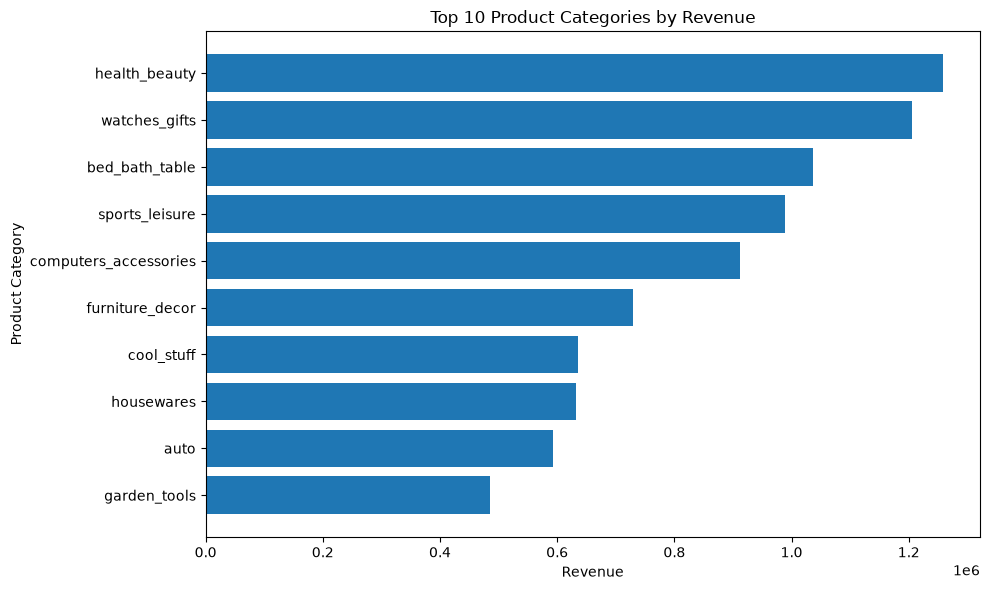

In [34]:
top_categories = category_revenue.head(10).sort_values("revenue")

plt.figure(figsize=(10, 6))

plt.barh(
    top_categories["product_category_name_english"],
    top_categories["revenue"]
)

plt.title("Top 10 Product Categories by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product Category")
plt.tight_layout()
plt.show()

## Key Finding

Revenue is distributed across several major product categories rather than being concentrated in a single category.

The top 10 categories account for 63.2% of categorized revenue. Health & Beauty is the largest category at 1.26M, followed by Watches & Gifts at 1.21M and Bed & Bath Table at 1.04M.

No individual category accounts for more than 10% of categorized revenue, suggesting that revenue is relatively diversified across the leading categories.